In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import shap

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

from xgboost import XGBRegressor

ROOT = Path.cwd().parent
print(ROOT)

DATA_RAW = ROOT/"data/raw"
DATA_PROCESSED = ROOT/"data/processed"

c:\Users\sebas\PycharmProjects\Git\BoxOffice_Oracle


In [2]:
model_df = pd.read_csv(
    DATA_RAW/"00_model_df.csv"
)

print(model_df.shape)
model_df.head()

(2255, 42)


,tconst,primaryTitle,startYear,opening_weekend_gross,opening_theaters,domestic_release_date,release_type,all_domestic_release_types,distributor,production_budget,...,actor_4,actor_5,actor_6,director_name,writer_name,actor_1_name,actor_2_name,actor_3_name,franchise,final_market_synopsis
0,tt0120667,Fantastic Four,2005.0,56061504.0,3602.0,2005-07-08,Wide,Wide,20th Century Fox,87500000.0,...,nm0004695,nm0573037,nm0512934,Tim Story,Mark Frost,Ioan Gruffudd,Michael Chiklis,Chris Evans,Fantastic Four,Scientist Reed Richards persuades his arrogant...
1,tt0121164,Corpse Bride,2005.0,19145480.0,3204.0,2005-09-16,Expands Wide,Expands Wide,Warner Bros.,40000000.0,...,nm0001808,nm0925768,NaN,Tim Burton,John August,Johnny Depp,Helena Bonham Carter,Emily Watson,NaN,"In a 19th-century European village, a young ma..."
2,tt0121766,Star Wars: Episode III - Revenge of the Sith,2005.0,108435841.0,3661.0,2005-05-19,Wide,Wide,20th Century Fox,115000000.0,...,nm0000168,nm0001519,nm0001751,George Lucas,George Lucas,Hayden Christensen,Natalie Portman,Ewan McGregor,Star Wars,"Years after the onset of the Clone Wars, the n..."
3,tt0167190,Hellboy,2004.0,23172440.0,3028.0,2004-04-02,Wide,Wide,Sony Pictures,60000000.0,...,nm0000457,nm1140344,nm0734558,Guillermo del Toro,Guillermo del Toro,Ron Perlman,Doug Jones,Selma Blair,Hellboy,"In the final days of World War II, the Nazis a..."
4,tt0200465,The Bank Job,2008.0,5935256.0,1603.0,2008-03-07,Wide,Wide,Lionsgate,20000000.0,...,nm0990547,nm0269077,nm0202810,Roger Donaldson,Dick Clement,Jason Statham,Saffron Burrows,Stephen Campbell Moore,NaN,Self-reformed petty criminal Terry Leather has...


In [3]:
model_df["franchise"].isna().mean()

np.float64(0.6620842572062084)

In [47]:
target = "log_opening_weekend_gross"

numeric_features = [
    # "opening_theaters",
    "production_budget",
    "runtime_minutes",
    "release_month",
    "release_day_of_year",
]

people_features = [
    "director_id",
    "writer_id",
    "actor_1",
    "actor_2",
    "actor_3",
]

categorical_features = [
    # "release_type",
    "distributor",
    "MPA_rating",
    "genre",
    "subgenre",
    "source",
    "production_method",
    "creative_type",
    "production_countries",
    "languages",
    # "franchise"
] + people_features

In [48]:
model_df = model_df[
    model_df["franchise"].isna() |
    (model_df["franchise"].astype(str).str.strip() == "")
].copy()

In [49]:
feature_cols = numeric_features + categorical_features

model_data = model_df[
    feature_cols + [target, "opening_weekend_gross"]
].copy()

X = model_data[feature_cols]
y = model_data[target]

print(X.shape)
print(y.shape)

(1493, 18)
(1493,)


In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [51]:
y_test_dollars = np.expm1(y_test)

In [52]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [53]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    pred_log = model.predict(X_test)

    r2_log = r2_score(y_test, pred_log)
    mae_log = mean_absolute_error(y_test, pred_log)

    pred_dollars = np.expm1(pred_log)

    mae_dollars = mean_absolute_error(y_test_dollars, pred_dollars)

    results = {
        "model": name,
        "r2_log": r2_log,
        "mae_log": mae_log,
        "mae_dollars": mae_dollars
    }

    return results, pred_log, pred_dollars

In [54]:
ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_results, ridge_pred_log, ridge_pred_dollars = evaluate_model(
    "Ridge Baseline",
    ridge_model,
    X_train,
    X_test,
    y_train,
    y_test
)

ridge_results

{'model': 'Ridge Baseline',
 'r2_log': 0.5402989713016917,
 'mae_log': 0.9891287203945243,
 'mae_dollars': 8234094.113494841}

In [55]:
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    ))
])

xgb_results, xgb_pred_log, xgb_pred_dollars = evaluate_model(
    "XGBoost Baseline",
    xgb_model,
    X_train,
    X_test,
    y_train,
    y_test
)

xgb_results

{'model': 'XGBoost Baseline',
 'r2_log': 0.598709897091242,
 'mae_log': 0.9119990104507624,
 'mae_dollars': 6757154.890749114}

In [13]:
results_df = pd.DataFrame([
    ridge_results,
    xgb_results
])

results_df

,model,r2_log,mae_log,mae_dollars
0,Ridge Baseline,0.540299,0.989129,8.234094e+06
1,XGBoost Baseline,0.598710,0.911999,6.757155e+06


In [14]:
plot_df = pd.DataFrame({
    "actual": y_test_dollars,
    "predicted": xgb_pred_dollars
})

fig = px.scatter(
    plot_df,
    x="actual",
    y="predicted",
    title="XGBoost Baseline: Actual vs Predicted",
    opacity=0.6
)

fig.add_shape(
    type="line",
    x0=plot_df["actual"].min(),
    y0=plot_df["actual"].min(),
    x1=plot_df["actual"].max(),
    y1=plot_df["actual"].max(),
)

fig.show()

In [15]:
X_train_transformed = (
    xgb_model.named_steps["preprocessor"]
    .transform(X_train)
)

X_test_transformed = (
    xgb_model.named_steps["preprocessor"]
    .transform(X_test)
)

feature_names = (
    xgb_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

trained_xgb = xgb_model.named_steps["model"]

c:\Users\sebas\miniconda3\envs\rr\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['franchise']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(
c:\Users\sebas\miniconda3\envs\rr\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['franchise']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(


In [16]:
explainer = shap.TreeExplainer(trained_xgb)

X_shap = X_test_transformed[:500]

shap_values = explainer.shap_values(X_shap)

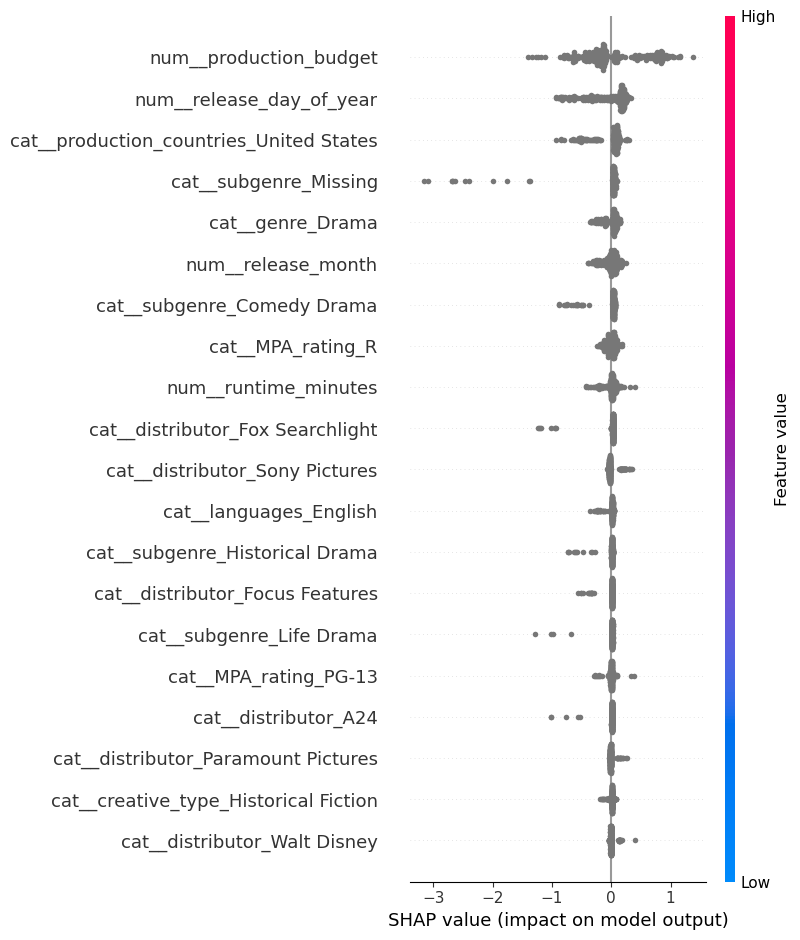

In [17]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names
)

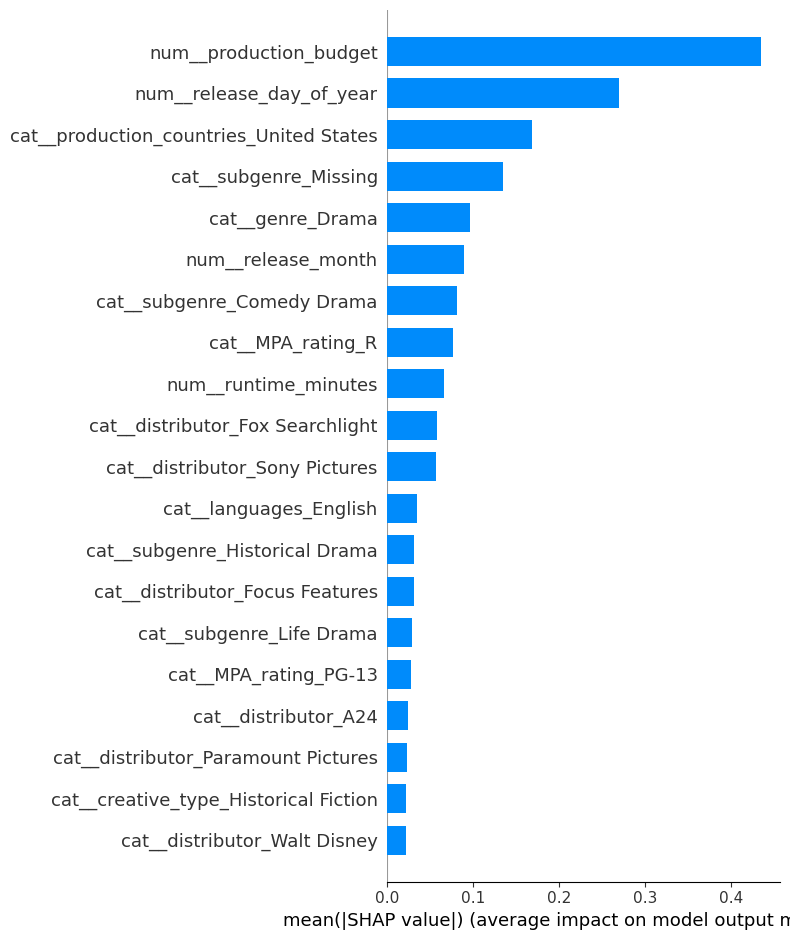

In [18]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    plot_type="bar"
)

## Notes on Feature Leakage, Forecasting Stages, and Modeling Tiers

During baseline modeling, opening theater count dramatically increased model performance:

- XGBoost without `opening_theaters` and `release_type`
  - R² ≈ 0.59

- XGBoost with `opening_theaters` and `release_type`
  - R² ≈ 0.90

This suggests that theater count and release strategy encode substantial downstream market information.

Although `opening_theaters` exists before opening weekend numerically, it is not an intrinsic movie attribute. Theater count is likely influenced by many hidden industry forecasting signals, including:

- trailer engagement
- social media hype
- advance ticket sales
- franchise familiarity
- tracking surveys
- marketing expectations
- exhibitor confidence
- critic expectations

Similarly, `release_type` (Wide, Limited, Expands Wide) likely reflects studio confidence and rollout strategy decisions informed by expected demand.

This creates an important distinction between:
- intrinsic movie characteristics
- market/distribution confidence signals

Rather than treating all features equally, the project may be better framed as a series of forecasting stages.

---

## Proposed Modeling Tiers

### Tier 1 — Intrinsic Metadata Model
Attempts to predict opening weekend using mostly intrinsic or structural movie characteristics.

Potential features:
- genre
- subgenre
- source material
- creative type
- production method
- runtime
- MPA rating
- production budget
- cast/director features
- engineered semantic features

Excludes:
- opening theater count
- release type

Goal:
Estimate how predictable audience demand is from movie characteristics alone.

---

### Tier 2 — Pre-Release Market Information Model
Adds real-world market-facing information that is publicly known before release.

Additional features:
- distributor
- release date/month/seasonality
- competition density
- Google Trends
- social media metrics
- trailer engagement

Goal:
Estimate how much additional predictive power comes from observable market positioning and audience awareness.

---

### Tier 3 — Distribution Strategy Model
Adds studio deployment and rollout decisions.

Additional features:
- opening theater count
- release type

Goal:
Estimate opening weekend after incorporating the industry's own distribution confidence signals.

This tier likely reflects not only movie quality or audience demand, but also the forecasting ability of studios and exhibitors themselves.

In [19]:
error_df = X_test.copy()

error_df["actual_log"] = y_test
error_df["pred_log"] = xgb_pred_log

error_df["actual_opening_weekend"] = np.expm1(y_test)
error_df["pred_opening_weekend"] = xgb_pred_dollars

error_df["abs_error"] = (
    error_df["actual_opening_weekend"] -
    error_df["pred_opening_weekend"]
).abs()

error_df.sort_values("abs_error", ascending=False).head(20)

,production_budget,runtime_minutes,release_month,release_day_of_year,distributor,MPA_rating,genre,subgenre,source,production_method,...,director_id,writer_id,actor_1,actor_2,actor_3,actual_log,pred_log,actual_opening_weekend,pred_opening_weekend,abs_error
2084,182000000.0,128.0,5,144,Walt Disney,PG,Adventure,Family Adventure,Based on Folk Tale/Legend/Fairytale,Animation/Live Action,...,nm0005363,nm0041864,nm0000226,nm4565815,nm4305463,18.331860,17.086140,91500929.0,26327896.0,65173033.0
1289,100000000.0,180.0,7,202,Universal,R,Drama,Biographical Drama,Based on Factual Book/Article,Live Action,...,nm0634240,nm0634240,nm0614165,nm1289434,nm0000354,18.227768,16.739407,82455420.0,18613664.0,63841756.0
1158,160000000.0,147.0,7,197,Warner Bros.,PG-13,Thriller/Suspense,Psychological Thriller,Original Screenplay,Animation/Live Action,...,nm0634240,nm0634240,nm0000138,nm0330687,nm0680983,17.955232,16.967384,62785337.0,23379832.0,39405505.0
876,25000000.0,130.0,8,222,Sony Pictures,PG-13,Drama,Romantic Drama,Based on Fiction Book/Short Story,Live Action,...,nm1682573,nm8631159,nm0515116,nm1682573,nm2809577,17.727867,16.217297,50016652.0,11042881.0,38973771.0
863,175000000.0,89.0,5,149,Walt Disney,PG,Adventure,Family Adventure,Original Screenplay,Digital Animation,...,nm0230032,nm0677037,nm0000799,nm2973712,nm0001652,18.036617,17.244913,68108790.0,30858200.0,37250590.0
1883,108000000.0,130.0,10,275,20th Century Fox,PG-13,Adventure,Survival Adventure,Based on Fiction Book/Short Story,Live Action,...,nm0000631,nm1206844,nm0000354,nm1567113,nm1325419,17.810193,16.749802,54308575.0,18808164.0,35500411.0
1034,185000000.0,93.0,6,174,Walt Disney,PG,Adventure,Family Adventure,Original Screenplay,Digital Animation,...,nm0028764,nm0028764,nm0531808,nm0175262,nm0000668,18.010056,17.244913,66323594.0,30858200.0,35465394.0
961,30000000.0,111.0,8,226,Sony Pictures,R,Thriller/Suspense,Action Thriller,Based on Short Film,Animation/Live Action,...,nm0088955,nm0088955,nm1663205,nm3107870,nm2271261,17.435959,15.332665,37354308.0,4559234.0,32795074.0
90,105000000.0,115.0,7,198,20th Century Fox,PG-13,Action,Action Thriller,Based on Fiction Book/Short Story,Animation/Live Action,...,nm0001639,nm0899113,nm0000226,nm0005256,nm0339304,17.770208,17.011803,52179887.0,24441732.0,27738155.0
27,75000000.0,90.0,10,275,Dreamworks SKG,PG,Adventure,Family Adventure,Original Screenplay,Digital Animation,...,nm0074426,nm5022110,nm0000226,nm0000134,nm0000250,17.678440,16.820017,47604606.0,20176252.0,27428354.0


In [20]:
results_df.to_csv(
    DATA_PROCESSED/"feature_testing/results/full_baseline_model_results.csv",
    index=False
)

error_df.to_csv(
    DATA_PROCESSED/"feature_testing/errors/full_baseline_xgb_test_errors.csv",
    index=False
)